In [ ]:
import sys
sys.path.append('/Users/nicholashorton/Documents/NBA Data')

from preprocessor import ProcessingConfig, DataProcessor
import pandas as pd


all_processable_columns = [
    'FGM', 'FGA',           
    'FG3M', 'FG3A',         
    'FTM', 'FTA',           
    'OREB', 'DREB', 'REB',  
    'AST',                  
    'STL',                  
    'BLK',                  
    'TOV',                  
    'PF',                   
    'PTS',                  
    'PLUS_MINUS',          

    'OFF_RATING',          
    'DEF_RATING',          
    'NET_RATING',           
    'E_OFF_RATING',         
    'E_DEF_RATING',         
    'E_NET_RATING',       
    'PACE',                 
    'E_PACE',              
    'PACE_PER40',          
    'POSS',                
    'PIE',                 

    'AST_PCT',            
    'AST_TOV',              
    'AST_RATIO',            
    'OREB_PCT',           
    'DREB_PCT',             
    'REB_PCT',             
    'TM_TOV_PCT',           
    'EFG_PCT',              
    'TS_PCT',               
    'USG_PCT',            
    'E_USG_PCT'            
]

config = ProcessingConfig(
    all_processable_columns=all_processable_columns,
    rolling_window=5,       # 5-game rolling average

    base_columns = [
        'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA',
        'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK',
        'TOV', 'PF', 'PTS', 'PLUS_MINUS',
        'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING',
        'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TOV',
        'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT',
        'E_TM_TOV_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT',
        'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
        'PACE_PER40', 'POSS', 'PIE'
    ],

    derived_metrics={},

    # Elo rating parameters (optional to customize)
    initial_elo=1500,
    k_factor=20,
    home_advantage=100,
    elo_width=400
)


print("Initializing DataProcessor...")
processor = DataProcessor(config)

print("\nProcessing data...")
print("  1. Load and merge advanced + traditional box scores")
print("  2. Add home/away context")
print("  3. Calculate rolling (5-game avg) and cumulative stats")
print("  4. Prepare game-level dataset (home vs away)")
print("  5. Calculate Elo ratings")
print("  6. Process player availability")
print("  7. Calculate difference metrics")

df = processor.process(
    advanced_path='/Users/nicholashorton/Documents/NBA Data/Data/Advanced_box_scores_2023.csv',
    traditional_path='/Users/nicholashorton/Documents/NBA Data/Data/traditional_box_scores_2023.csv',
    player_boxscores='/Users/nicholashorton/Documents/NBA Data/Data/player_box_scores_2023.csv'
)

# Filter nonsensical columns

def filter_nonsensical_columns(df):
    """
    Remove cumulative versions of rate/percentage stats.
    Cumulative only makes sense for counting stats.
    """
    # Define rate/percentage stats that shouldn't have cumulative versions
    rate_stats = [
        'OFF_RATING', 'DEF_RATING', 'NET_RATING',
        'E_OFF_RATING', 'E_DEF_RATING', 'E_NET_RATING',
        'PACE', 'E_PACE', 'PACE_PER40',
        'PIE',
        'AST_PCT', 'AST_TOV', 'AST_RATIO',
        'OREB_PCT', 'DREB_PCT', 'REB_PCT',
        'TM_TOV_PCT',
        'EFG_PCT', 'TS_PCT',
        'USG_PCT', 'E_USG_PCT',
        'FG_PCT', 'FG3_PCT', 'FT_PCT'
    ]

    # lsit of columns to drop
    cols_to_drop = []

    for stat in rate_stats:
        # Drop cumulative versions (both home and away)
        cumulative_home = f'{stat}_cumulative_home'
        cumulative_away = f'{stat}_cumulative_away'

        if cumulative_home in df.columns:
            cols_to_drop.append(cumulative_home)
        if cumulative_away in df.columns:
            cols_to_drop.append(cumulative_away)

    # Drop  columns
    if cols_to_drop:
        print(f"\nFiltering out {len(cols_to_drop)} nonsensical cumulative columns...")
        df = df.drop(columns=cols_to_drop)
        print(f"Examples dropped: {', '.join(cols_to_drop[:5])}{'...' if len(cols_to_drop) > 5 else ''}")

    return df

print("\nFiltering nonsensical columns...")
print("(Removing cumulative versions of rate/percentage stats)")
df = filter_nonsensical_columns(df)

print(f"\n{'='*70}")
print(f"Processing complete!")
print(f"{'='*70}")
print(f"Total games processed: {len(df)}")
print(f"Total features: {len(df.columns)}")

print(f"\n{'='*70}")
print("Data Quality Check:")
print(f"{'='*70}")

# Check for missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 10]

if len(high_missing) > 0:
    print(f"\n Columns with >10% missing values:")
    for col, pct in high_missing.items():
        print(f"  {col}: {pct:.1f}%")
else:
    print("\n No columns with >10% missing values")

# Check for infinite values
inf_cols = [col for col in df.columns if df[col].dtype in ['float64', 'int64'] and
            (df[col] == float('inf')).any() or (df[col] == float('-inf')).any()]

if len(inf_cols) > 0:
    print(f"\n Columns with infinite values: {inf_cols}")
else:
    print("No infinite values detected")

print(f"\n{'='*70}")
print("Ready for modeling!")
print(f"{'='*70}")


Initializing DataProcessor...

Processing data...
This will:
  1. Load and merge advanced + traditional box scores
  2. Add home/away context
  3. Calculate rolling (5-game avg) and cumulative stats
  4. Prepare game-level dataset (home vs away)
  5. Calculate Elo ratings
  6. Process player availability
  7. Calculate difference metrics
Loading and merging data...
Adding context features...

Created 0 cumulative derived metrics:

Created 0 rolling derived metrics:
⚠️  Warning: These columns have issues: []
Preparing game-level dataset...
Calculating Elo ratings...
Calculating derived metrics...

Filtering nonsensical columns...
(Removing cumulative versions of rate/percentage stats)

Filtering out 42 nonsensical cumulative columns...
Examples dropped: OFF_RATING_cumulative_home, OFF_RATING_cumulative_away, DEF_RATING_cumulative_home, DEF_RATING_cumulative_away, NET_RATING_cumulative_home...

Processing complete!
Total games processed: 1230
Total features: 130

First few rows:
     SEA

In [ ]:
df.head()

,SEASON_ID_home,TEAM_ID_home,TEAM_NAME_home,GAME_ID,GAME_DATE,WL,FGM_cumulative_home,FGM_rolling_home,FGA_cumulative_home,FGA_rolling_home,...,HOME_ELO_POST,AWAY_ELO_POST,HOME_WIN_PROB,missing_players_home,missing_impact_home,missing_star_home,missing_players_away,missing_impact_away,missing_star_away,WIN
245,22023,1610612743,Denver Nuggets,22300061,2023-10-24,1,NaN,NaN,NaN,NaN,...,1508.638440,1491.361560,0.640065,0,0.000000,0,0,0.000000,0,1
286,22023,1610612744,Golden State Warriors,22300062,2023-10-24,0,NaN,NaN,NaN,NaN,...,1487.198700,1512.801300,0.640065,0,0.000000,0,0,0.000000,0,0
1189,22023,1610612766,Charlotte Hornets,22300063,2023-10-25,1,NaN,NaN,NaN,NaN,...,1507.198700,1492.801300,0.640065,0,0.000000,0,0,0.000000,0,1
698,22023,1610612754,Indiana Pacers,22300064,2023-10-25,1,NaN,NaN,NaN,NaN,...,1516.557010,1483.442990,0.640065,0,0.000000,0,0,0.000000,0,1
616,22023,1610612752,New York Knicks,22300065,2023-10-25,0,NaN,NaN,NaN,NaN,...,1487.198700,1512.801300,0.640065,0,0.000000,0,0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,22023,1610612760,Oklahoma City Thunder,22301196,2024-04-14,1,3599.0,44.0,7227.0,88.6,...,1694.313857,1633.195455,0.622941,0,0.000000,0,5,3.038872,1,1
943,22023,1610612759,San Antonio Spurs,22301197,2024-04-14,1,3389.0,41.0,7345.0,89.8,...,1386.928833,1236.294203,0.786719,5,2.614281,1,6,2.475118,0,1
326,22023,1610612744,Golden State Warriors,22301198,2024-04-14,1,3537.0,42.6,7421.0,85.6,...,1639.894492,1343.797948,0.905366,2,1.233664,1,9,4.374455,1,1
408,22023,1610612746,LA Clippers,22301199,2024-04-14,0,3432.0,44.0,7004.0,90.6,...,1549.118558,1524.005988,0.711010,5,3.111762,1,4,2.416237,1,0


In [3]:
df = df.drop(columns=['SEASON_ID_home', 'TEAM_ID_home', 'TEAM_NAME_home', 'GAME_ID','GAME_DATE', 'TEAM_ID_away','TEAM_NAME_away','HOME_ELO_POST','AWAY_ELO_POST','WL'])
df.dropna(inplace=True)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['WIN'])
y = df['WIN']
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=42, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Perform PCA on the scaled training data
from sklearn.decomposition import PCA

# Choose the number of components (e.g., enough to explain 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of PCA components to explain 95% variance: {pca.n_components_}")

# Optionally, view explained variance ratio
explained_var = pd.Series(pca.explained_variance_ratio_)
print("Explained variance ratio per component:")
print(explained_var)

# If you want to see the loadings (feature importance for each component)
loadings = pd.DataFrame(pca.components_.T, index=X_train.columns, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

Number of PCA components to explain 95% variance: 27
Explained variance ratio per component:
0     0.293040
1     0.100549
2     0.093688
3     0.047680
4     0.045264
5     0.039564
6     0.034795
7     0.027376
8     0.025554
9     0.025220
10    0.024142
11    0.019698
12    0.019655
13    0.016832
14    0.015847
15    0.013998
16    0.013631
17    0.012927
18    0.012174
19    0.011348
20    0.010887
21    0.009782
22    0.009171
23    0.008246
24    0.007414
25    0.007040
26    0.006753
dtype: float64


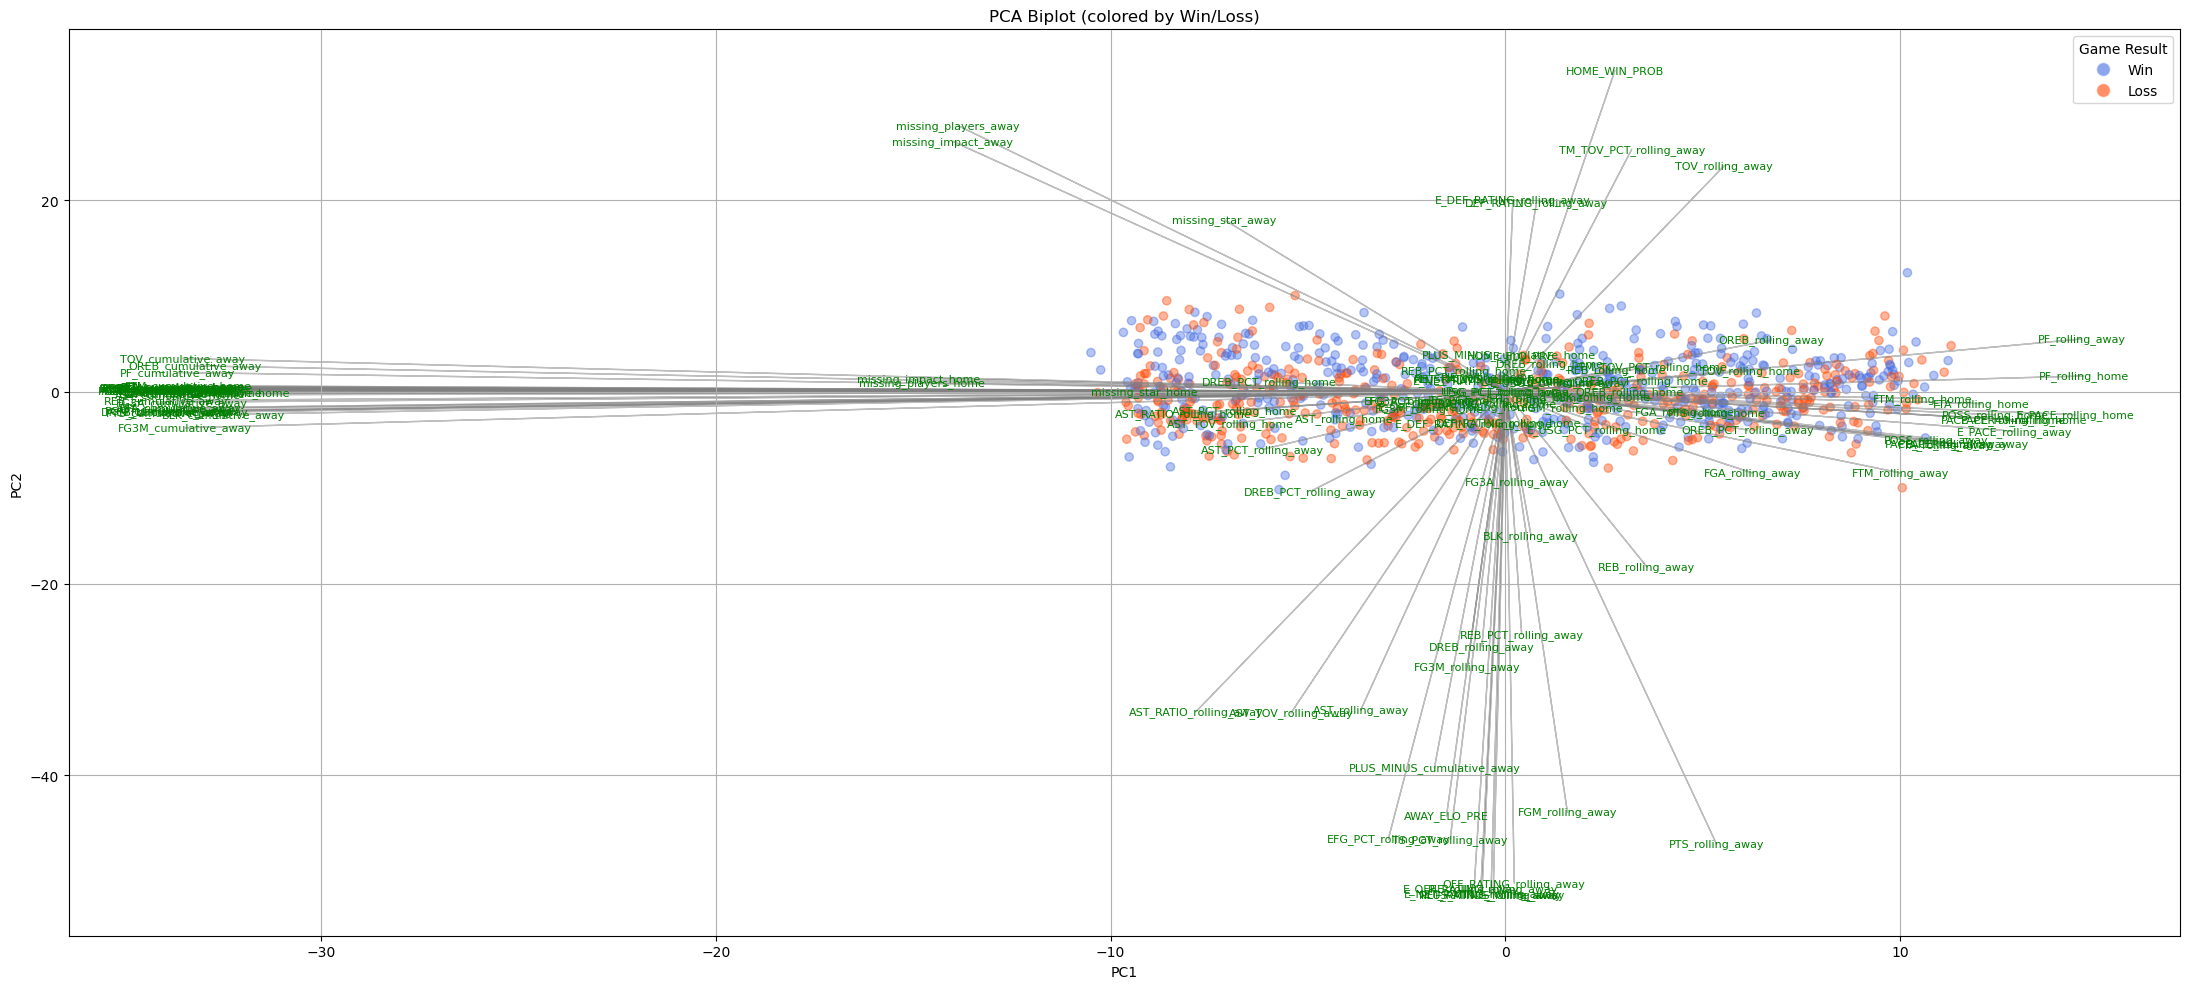

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Project the training data onto the first two principal components
pc1 = X_train_pca[:, 0]
pc2 = X_train_pca[:, 1]

# Color by win/loss
colors = np.where(y_train.values == 1, 'royalblue', 'orangered')
labels = np.where(y_train.values == 1, 'Win', 'Loss')

plt.figure(figsize=(22, 10))
scatter = plt.scatter(pc1, pc2, c=colors, alpha=0.4, label=None)

# Plot feature vectors (loadings)
scale = 200
for i, feature in enumerate(X_train.columns):
    plt.arrow(0, 0, 
              loadings.iloc[i, 0]*scale,  # scale for visibility
              loadings.iloc[i, 1]*scale, 
              color='gray', alpha=0.5)
    plt.text(loadings.iloc[i, 0]*scale, 
             loadings.iloc[i, 1]*scale, 
             feature, color='green', ha='center', va='center', fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot (colored by Win/Loss)')
plt.grid(True)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Win', markerfacecolor='royalblue', markersize=10, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Loss', markerfacecolor='orangered', markersize=10, alpha=0.6)
]
plt.legend(handles=legend_elements, title='Game Result')
plt.tight_layout()
plt.show()

In [32]:
top_loadings

NameError: name 'top_loadings' is not defined

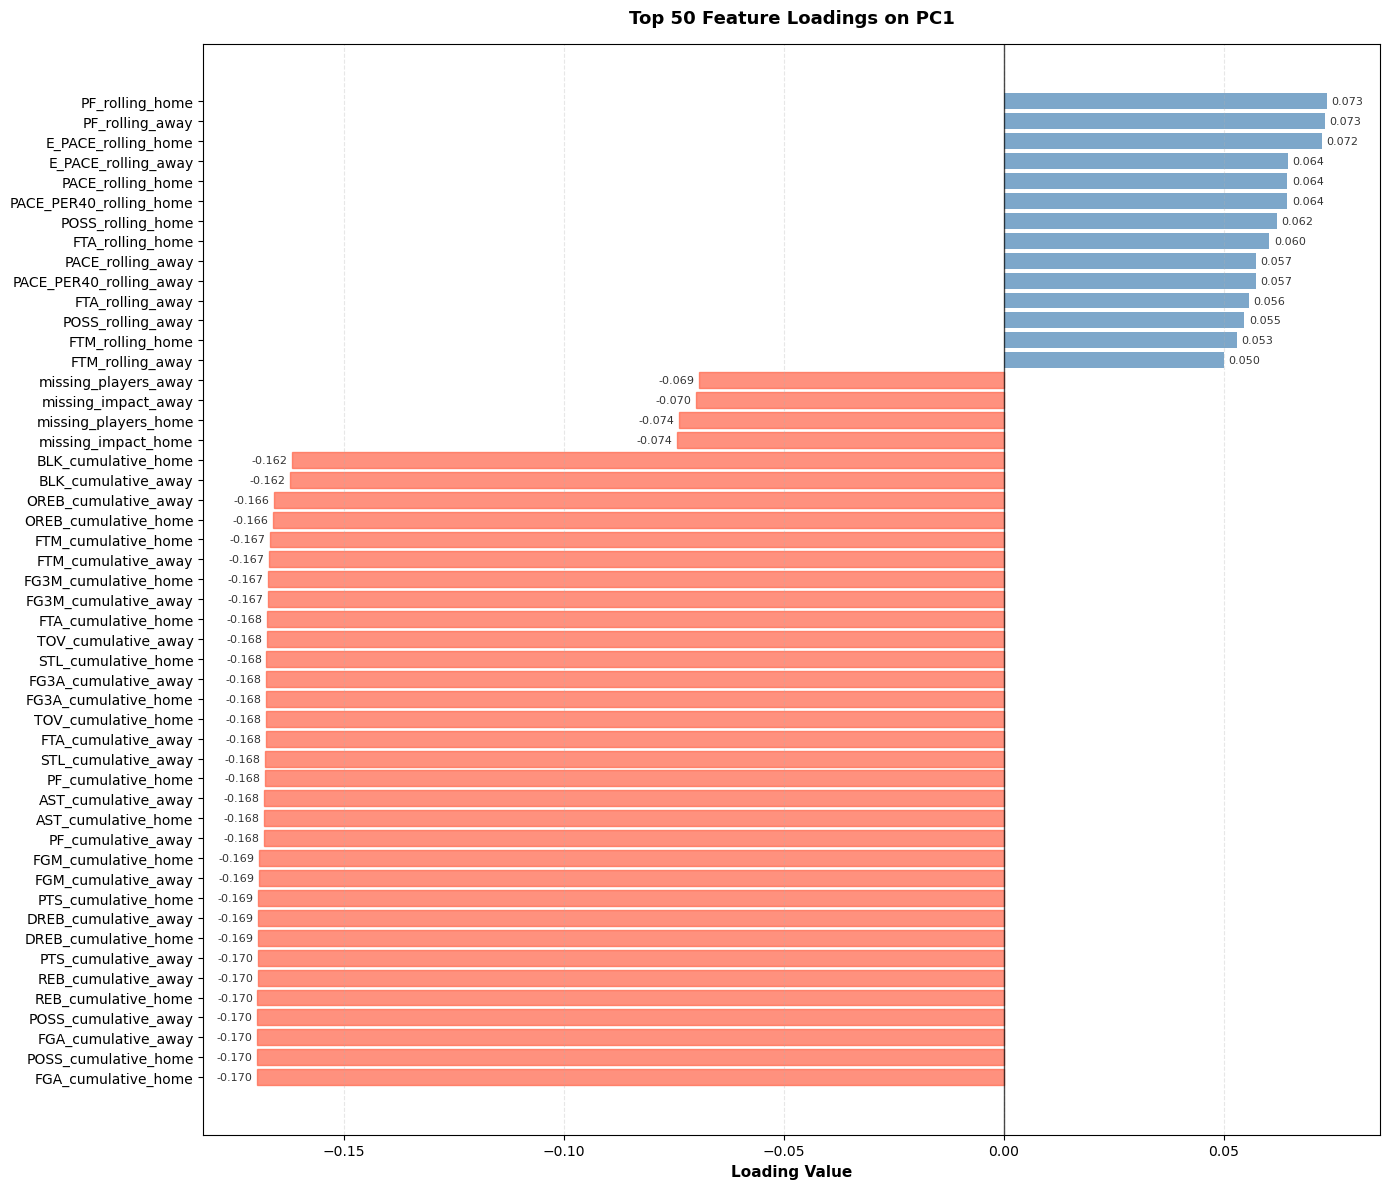

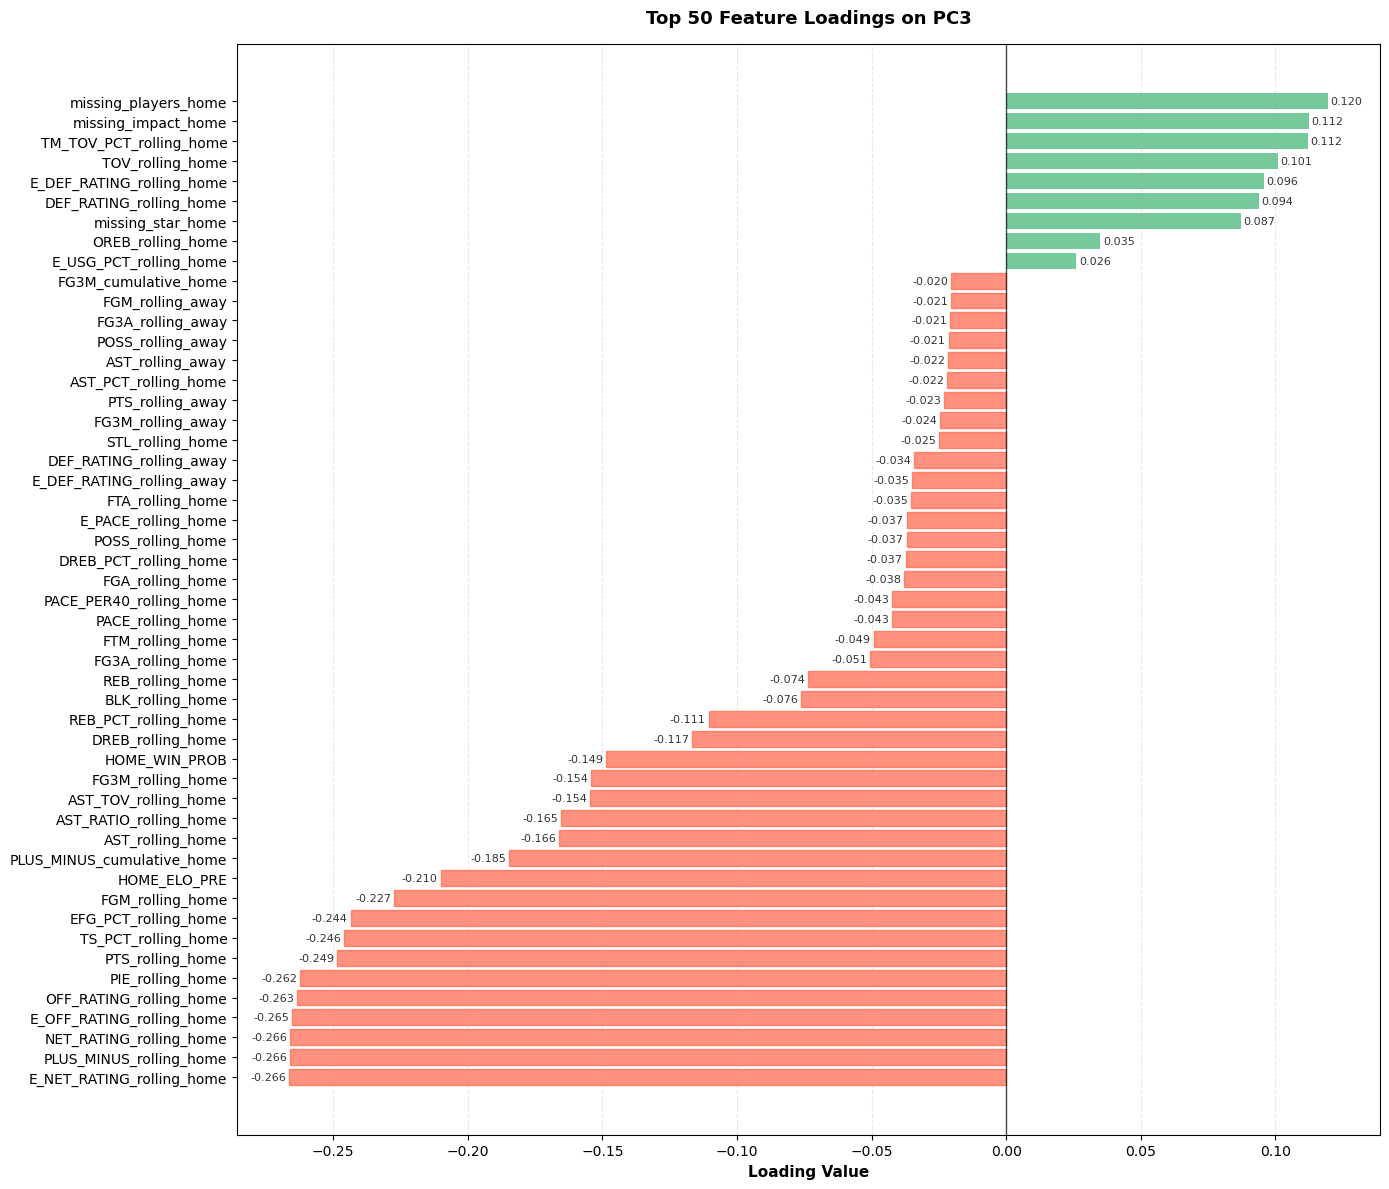

In [36]:
def create_loadings_plot(loadings, pc_num=0, top_n=30, color='steelblue'):
    """
    Creates a clean horizontal bar plot for PC loadings.

    Parameters:
    -----------
    loadings : DataFrame, shape (n_features, n_components)
        PCA loadings (components)
    pc_num : int, default=0
        Which PC to plot (0 for PC1, 1 for PC2, etc.)
    top_n : int, default=20
        Number of top features to display
    color : str, default='steelblue'
        Bar color
    """
    pc_loadings = loadings.iloc[:, pc_num].copy()

    # Get top N by absolute value
    top_loadings = pc_loadings.reindex(
        pc_loadings.abs().nlargest(top_n).index
    ).sort_values()

    fig, ax = plt.subplots(figsize=(14, 12))

    # Create horizontal bar chart
    bars = ax.barh(range(len(top_loadings)), top_loadings.values, color=color, alpha=0.7)

    # Color bars by sign
    for i, (bar, val) in enumerate(zip(bars, top_loadings.values)):
        if val < 0:
            bar.set_color('tomato')

    ax.set_yticks(range(len(top_loadings)))
    ax.set_yticklabels(top_loadings.index, fontsize=10)
    ax.set_xlabel(f'Loading Value', fontsize=11, weight='bold')
    ax.set_title(f'Top {top_n} Feature Loadings on PC{pc_num+1}',
                fontsize=13, weight='bold', pad=15)
    ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.7)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_loadings.values)):
        label_x = val + (0.001 if val > 0 else -0.001)
        ha = 'left' if val > 0 else 'right'
        ax.text(label_x, i, f'{val:.3f}',
               va='center', ha=ha, fontsize=8, alpha=0.8)

    plt.tight_layout()
    return fig, top_loadings.to_frame(name=f'PC{pc_num+1}_loading')


# Plot 1: Biplot with top features
# fig1 = create_biplot(X_train_pca, y_train, loadings, X_train,
#                     n_top_features=60)
# plt.show()

# Plot 2: PC1 loadings
fig2, pc1_df = create_loadings_plot(loadings, pc_num=0, top_n=50, color='steelblue')
plt.show()

# Plot 3: PC2 loadings
fig3, pc3_df = create_loadings_plot(loadings, pc_num=2, top_n=50, color='mediumseagreen')
plt.show()

In [37]:
# pc1_df.to_csv('pc1.csv')
# pc2_df.to_csv('pc2.csv')
pc3_df.to_csv('pc3.csv')

# Create baseline

In [ ]:
from sklearn.metrics import accuracy_score

#  Baseline 1: Always predict home team wins 
always_home_pred = [1] * len(y_test)
print("Baseline (Always Home Wins) Accuracy:", accuracy_score(y_test, always_home_pred))

# Baseline 2: Predict team with higher ELO wins
test_indices = y_test.index
df_elo = df.copy()
elo_pred = (df_elo.loc[test_indices, 'HOME_ELO_PRE'] > df_elo.loc[test_indices, 'AWAY_ELO_PRE']).astype(int).values
elo_true = df_elo.loc[test_indices, 'WIN'].values

print("Baseline (Higher ELO Wins) Accuracy:", accuracy_score(elo_true, elo_pred))

Baseline (Always Home Wins) Accuracy: 0.5720164609053497
Baseline (Higher ELO Wins) Accuracy: 0.6255144032921811


# Logistic Regression

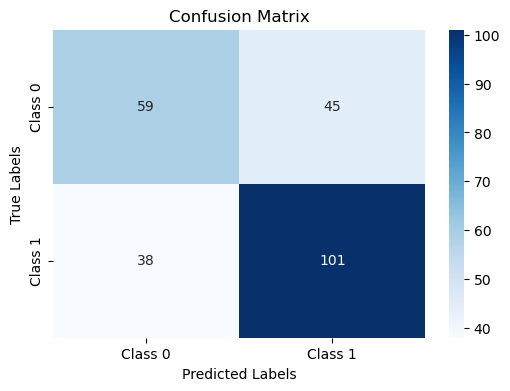

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression(penalty='l2', solver='saga', random_state=42)
model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)




import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = model.predict_proba(X_test_pca)[:, 1]  # Probability for class 1

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Step 5: Print the Classification Report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

ROC AUC Score: 0.7186
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59       104
           1       0.69      0.73      0.71       139

    accuracy                           0.66       243
   macro avg       0.65      0.65      0.65       243
weighted avg       0.66      0.66      0.66       243



In [27]:
from sklearn.svm import SVC
import xgboost as xgb

# SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
y_proba_svm = svm.predict_proba(X_test_pca)[:, 1]

# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_pca, y_train)
y_pred_xgb = xgb_model.predict(X_test_pca)
y_proba_xgb = xgb_model.predict_proba(X_test_pca)[:, 1]

# Compare Results
def print_metrics(name, y_true, y_pred, y_proba):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

print_metrics("SVM", y_test, y_pred_svm, y_proba_svm)
print_metrics("XGBoost", y_test, y_pred_xgb, y_proba_xgb)


SVM Results:
Accuracy: 0.6584362139917695
ROC AUC: 0.6961815163254012
Confusion Matrix:
 [[ 59  45]
 [ 38 101]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.57      0.59       104
           1       0.69      0.73      0.71       139

    accuracy                           0.66       243
   macro avg       0.65      0.65      0.65       243
weighted avg       0.66      0.66      0.66       243


XGBoost Results:
Accuracy: 0.6378600823045267
ROC AUC: 0.6923768677365799
Confusion Matrix:
 [[62 42]
 [46 93]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.60      0.58       104
           1       0.69      0.67      0.68       139

    accuracy                           0.64       243
   macro avg       0.63      0.63      0.63       243
weighted avg       0.64      0.64      0.64       243



In [28]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()

nb.fit(X_train_pca, y_train)

y_pred_nb = nb.predict(X_test_pca)
y_proba_nb = nb.predict_proba(X_test_pca)[:, 1]

print_metrics("Gaussian Naive Bayes", y_test, y_pred_nb, y_proba_nb)


Gaussian Naive Bayes Results:
Accuracy: 0.6419753086419753
ROC AUC: 0.7002628666297731
Confusion Matrix:
 [[59 45]
 [42 97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.57      0.58       104
           1       0.68      0.70      0.69       139

    accuracy                           0.64       243
   macro avg       0.63      0.63      0.63       243
weighted avg       0.64      0.64      0.64       243



In [ ]:
from sklearn.metrics import f1_score

logreg = LogisticRegression(random_state=42, max_iter=2000)

best_svm = SVC(
    C=1,
    gamma='scale',
    kernel='rbf',
    probability=True,
    random_state=42
)
best_xgb = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=2,
    n_estimators=100,
    subsample=0.7
)

# Fit base models
logreg.fit(X_train_pca, y_train)
best_svm.fit(X_train_pca, y_train)
best_xgb.fit(X_train_pca, y_train)
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Base models (with best params)
base_models = [
    ('logreg', logreg),
    ('svm', svm),
    ('xgb', xgb_model),
    ('nb',nb)
]

# Meta-classifier
meta_clf = LogisticRegression(max_iter=1000, random_state=42)
from sklearn.ensemble import StackingClassifier

# Create StackingClassifier
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_clf,
    cv=5,
    passthrough=False, 
    n_jobs=-1
)

# Fit and predict
stack_model.fit(X_train_pca, y_train)
y_pred_stack = stack_model.predict(X_test_pca)
y_proba_stack = stack_model.predict_proba(X_test_pca)[:, 1]

print_metrics("Stacking Meta-Model", y_test, y_pred_stack, y_proba_stack)

from itertools import combinations

def evaluate_combinations(model_dict, meta_clf, X_train, y_train, X_test, y_test, name_prefix=""):
    results = []
    for n_models in range(2, len(model_dict)+1):
        for combo in combinations(model_dict.items(), n_models):
            name = "+".join([m[0] for m in combo])
            estimators = list(combo)
            stack = StackingClassifier(
                estimators=estimators,
                final_estimator=meta_clf,
                cv=5,
                n_jobs=-1,
                passthrough=False
            )
            stack.fit(X_train, y_train)
            y_pred = stack.predict(X_test)
            y_proba = stack.predict_proba(X_test)[:, 1]
            metrics = print_metrics(f"Stacking ({name_prefix}{name})", y_test, y_pred, y_proba)
            results.append({
                "stack": f"{name_prefix}{name}",
                **metrics  # make print_metrics return dict of metrics like accuracy, f1, etc.
            })
    return pd.DataFrame(results)

# Ensure print_metrics returns a dict of scores.
# Example:
def print_metrics(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)
    print(f"{name}: accuracy={acc:.3f}, f1={f1:.3f}, roc_auc={roc:.3f}")
    return {"accuracy": acc, "f1": f1, "roc_auc": roc}


logreg_df = evaluate_combinations(model_dict, LogisticRegression(max_iter=1000, random_state=42),
                                  X_train_pca, y_train, X_test_pca, y_test, name_prefix="LRmeta-")
xgb_meta_df = evaluate_combinations(model_dict, xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                                    X_train_pca, y_train, X_test_pca, y_test, name_prefix="XGBmeta-")
svm_meta_df = evaluate_combinations(model_dict, SVC(C=1, gamma='scale', kernel='rbf', probability=True, random_state=42),
                                    X_train_pca, y_train, X_test_pca, y_test, name_prefix="SVMmeta-")

# Combine everything and rank
all_results = pd.concat([logreg_df, xgb_meta_df, svm_meta_df], ignore_index=True)
ranked = all_results.sort_values(by="roc_auc", ascending=False)  # change to whatever metric you prefer
print(ranked.reset_index(drop=True))


In [43]:
ranked

,stack,accuracy,f1,roc_auc
27,SVMmeta-xgb+nb,0.687243,0.730496,0.744501
1,LRmeta-logreg+xgb,0.674897,0.716846,0.736649
8,LRmeta-logreg+xgb+nb,0.654321,0.697842,0.733467
30,SVMmeta-logreg+xgb+nb,0.662551,0.696296,0.732914
5,LRmeta-xgb+nb,0.679012,0.725352,0.730631
23,SVMmeta-logreg+xgb,0.666667,0.698885,0.730493
6,LRmeta-logreg+svm+xgb,0.666667,0.707581,0.726273
10,LRmeta-logreg+svm+xgb+nb,0.679012,0.723404,0.724958
3,LRmeta-svm+xgb,0.679012,0.721429,0.724751
17,XGBmeta-logreg+svm+xgb,0.683128,0.713755,0.724682
